In [170]:
import numpy as np
from matplotlib import pyplot as plt
from decimal import Decimal, getcontext, ROUND_HALF_UP
import math

getcontext().rounding = ROUND_HALF_UP

In [171]:
def mu(x, k, mean):
    sum = np.sum((x-mean)**k)
    return sum/np.size(x)

def mode(x):
    unique, counts = np.unique(x, return_counts=True)
    max_count = np.max(counts)
    modes = unique[counts == max_count]
    return modes

def asymmetry(x):
    mean = np.mean(x)
    mu_3 = mu(x, 3, mean)
    mu_2 = mu(x, 2, mean)
    return mu_3/mu_2**(3/2)

In [172]:
n = 25
x = np.random.exponential(scale=1, size=n)
print(x)

[8.71211639e-01 2.95538513e-01 3.91399899e-01 3.61720037e-01
 6.82209133e-02 1.36234519e-01 7.44987616e-01 5.90527527e-01
 2.22662209e+00 1.22359217e+00 1.32479307e+00 3.56464567e-01
 3.40078104e+00 3.00924818e-01 1.24620682e+00 5.51197776e-01
 6.84972413e-01 8.64314888e-01 1.02169545e+00 8.91781969e-01
 2.77408243e-01 5.25617809e+00 3.84293986e-03 1.86135661e+00
 1.71788339e+00]


## a)

In [173]:
median = np.median(x)
scope = x.max() - x.min()
mean = np.mean(x)
asymmetry_x = asymmetry(x)
modes = mode(x)

In [174]:
print(f"медиана = {median}\n размах = {scope}\n коэффициент ассиметрии = {asymmetry_x}\n моды: {modes if np.size(modes)<n else 'всего по 1'}")

медиана = 0.7449876159175836
 размах = 5.252335150904736
 коэффициент ассиметрии = 2.221838016660939
 моды: всего по 1


## b)

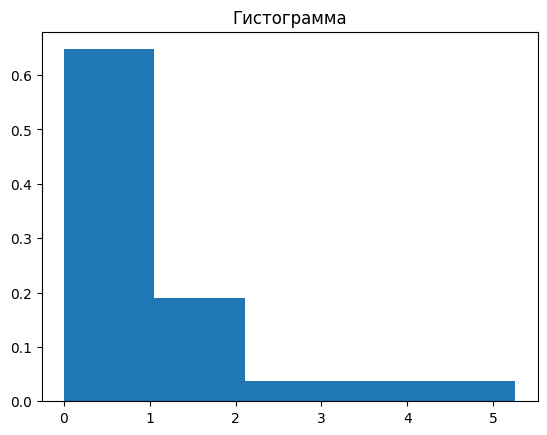

In [175]:
plt.hist(x, bins=int(Decimal(1+np.log2(n))), density=True)
plt.title("Гистограмма")
plt.show()

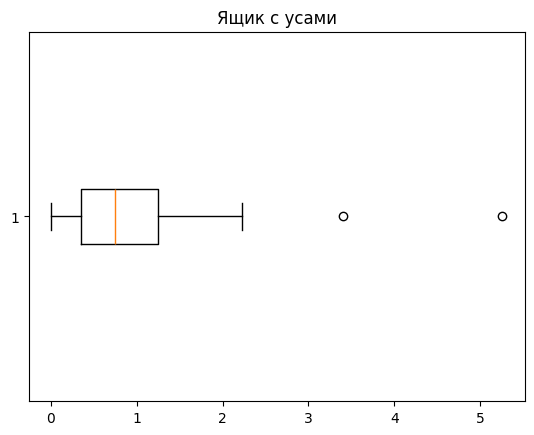

In [176]:
plt.boxplot(x, vert=False)
plt.title("Ящик с усами")
plt.show()

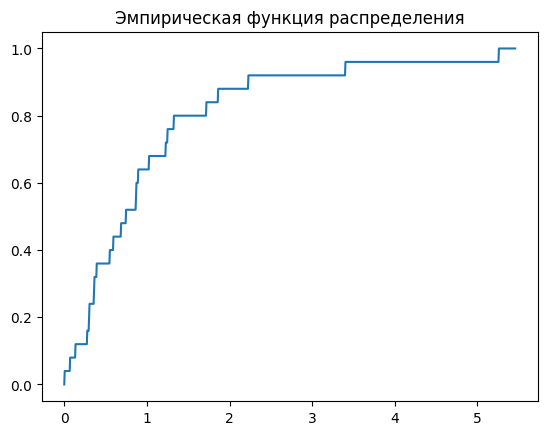

In [177]:
def empirical_cdf(data, x):
    return np.sum(data <= x)/np.size(data)

ax_x = np.linspace(0, x.max()+0.2, 1000)
ax_y = [empirical_cdf(x, i) for i in ax_x]

plt.plot(ax_x, ax_y)
plt.title("Эмпирическая функция распределения")
plt.show()

## c)

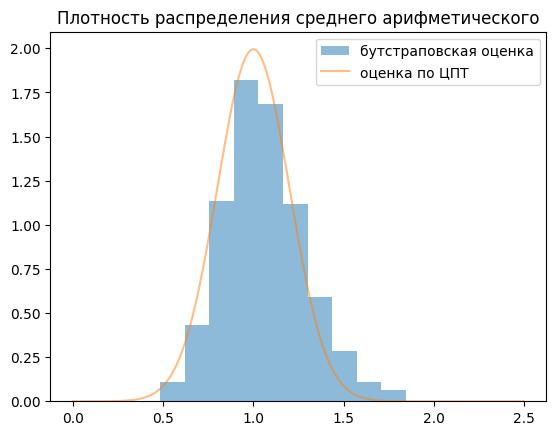

In [178]:
def subsample(x, n):
    mask = np.random.randint(0, n, size=n)
    sub_x = x[mask]
    return sub_x

def gaussian_pdf(x, mu=1, sigma=1/5):
    return (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-(x - mu)**2 / (2 * sigma**2))

def bootstrap_mean(x, n, N):
    statistic = np.zeros(N)
    for i in range (0, N):
        sub_x = subsample(x, n)
        statistic[i] = np.mean(sub_x)

    bins=int(Decimal(1+np.log2(N)))
    plt.hist(statistic, bins=bins, density=True,  alpha=0.5, label="бутстраповская оценка")

    mu = 1
    sigma = 1/5
    ax_x = np.linspace(0, 2.5, N)
    ax_y = gaussian_pdf(ax_x, mu, sigma)
    plt.plot(ax_x, ax_y, alpha=0.5, label="оценка по ЦПТ")
    plt.title("Плотность распределения среднего арифметического")
    plt.legend()
    plt.show()

N = 1000
bootstrap_mean(x, np.size(x), N)

## d)

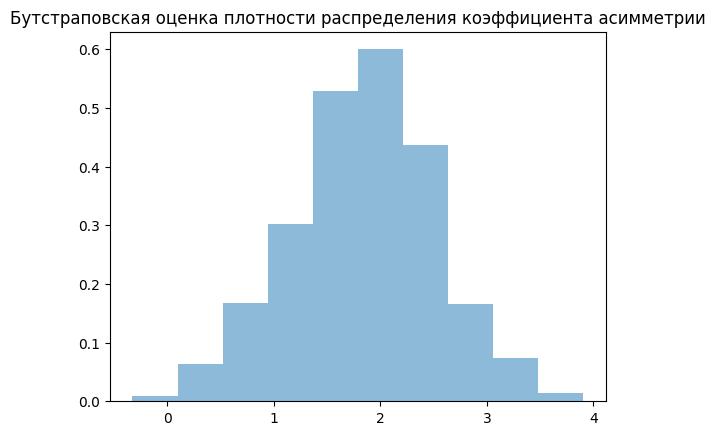

In [179]:
def bootstrap_asymmetry(x, n, N):
    statistic = np.zeros(N)
    for i in range (0, N):
        sub_x = subsample(x, n)
        statistic[i] = asymmetry(sub_x)

    bins=int(Decimal(1+np.log2(N)))
    plt.hist(statistic, bins=bins, density=True,  alpha=0.5)
    plt.title("Бутстраповская оценка плотности распределения коэффициента асимметрии")
    plt.show()
    return statistic


statistic = bootstrap_asymmetry(x, np.size(x), N)

In [180]:
probability = np.mean(statistic < 1)
print(f"P(asymmetry < 1) = {probability}")

P(asymmetry < 1) = 0.111


## e)

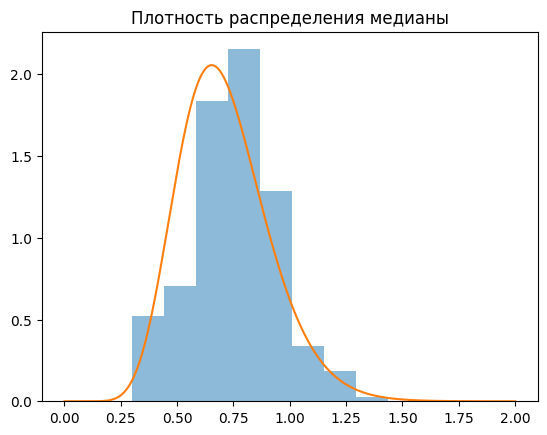

In [182]:
def bootstrap_median(x, n, N):
    statistic = np.zeros(N)
    for i in range (0, N):
        sub_x = subsample(x, n)
        statistic[i] = np.median(sub_x)

    bins=int(Decimal(1+np.log2(N)))
    plt.hist(statistic, bins=bins, density=True,  alpha=0.5, label="бутстраповская оценка")

    ax_x = np.linspace(0, 2, N)
    ax_y = np.zeros(N)
    for i in range((n+1)//2, n+1):
        ax_y += math.comb(n, i) * np.exp(-ax_x*(n-i)) * (1 - np.exp(-ax_x))**(i-1) * (n*np.exp(-ax_x) - n + i)
    
    plt.plot(ax_x, ax_y, label="плотность распределения")
    plt.title("Плотность распределения медианы")
    plt.show()

bootstrap_median(x, np.size(x), N)
